
# 🎯 Gradient Descent — The Complete Guide
### From Linear Regression to Full Mathematical Derivation, Code, and Intuition

> **Goal of this notebook:** after reading this once, top to bottom, you should **never need to look anywhere else** to understand Gradient Descent — where it comes from, why every term in the formula exists, how to derive it yourself on paper, how to code it from scratch, and how it connects to everything else in Machine Learning (Linear Regression, Logistic Regression, Deep Learning).

We build everything **bottom-up**: starting from plain Linear Regression, deriving the cost function, deriving the gradient term-by-term with full calculus, then coding it, visualizing it, breaking it on purpose (bad learning rates), fixing it, extending it to multiple variables, comparing Batch vs Stochastic vs Mini-Batch, and finally validating our from-scratch code against `scikit-learn`.

---

## 📑 Table of Contents

1. [The Big Picture — What Problem Are We Solving?](#part1)
2. [Linear Regression From Scratch — Building the Model](#part2)
3. [Two Ways to Solve Linear Regression: Closed-Form vs Iterative](#part3)
4. [Calculus Refresher — The Tools We Need](#part4)
5. [The Full Derivation — Every Term, Explained](#part5)
6. [The Update Rule & The Role of the Learning Rate](#part6)
7. [Coding Gradient Descent From Scratch (1D: solving for $b$ only)](#part7)
8. [The Learning Rate Experiment — Too Small, Just Right, Too Big](#part8)
9. [Full 2D Gradient Descent — Solving for $m$ and $b$ Together (with Animation)](#part9)
10. [The Loss Landscape — Contours, the 3D Bowl, Convexity & Saddle Points](#part10)
11. [Effect of Feature Scaling on Gradient Descent](#part11)
12. [Batch vs Stochastic vs Mini-Batch Gradient Descent](#part12)
13. [The Master Key — Gradient Descent Beyond Linear Regression](#part13)
14. [Validating Against `scikit-learn`](#part14)
15. [Cheat Sheet & Official References](#part15)



## ⚙️ Setup

Run this first. It imports everything we'll use throughout the notebook and generates **one consistent synthetic dataset** that every section will reuse — so the numbers you see in later sections are always comparable.


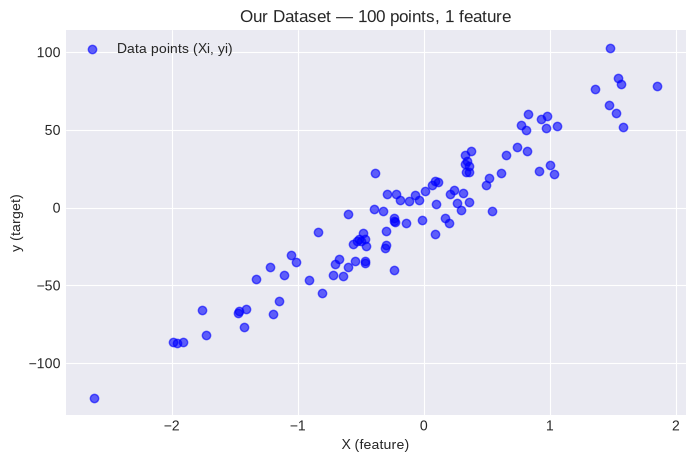

n (number of samples) = 100
X shape = (100, 1), y shape = (100, 1)


In [123]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display, Markdown
import plotly.graph_objects as go
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# ---- One dataset used throughout the whole notebook ----
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
y = y.reshape(-1, 1)
n = float(len(X))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data points (Xi, yi)')
plt.title("Our Dataset — 100 points, 1 feature")
plt.xlabel("X (feature)")
plt.ylabel("y (target)")
plt.legend()
plt.show()

print(f"n (number of samples) = {int(n)}")
print(f"X shape = {X.shape}, y shape = {y.shape}")



<a id="part1"></a>
## 1. The Big Picture — What Problem Are We Solving?

Every supervised Machine Learning algorithm follows the **same three-step recipe**:

| Step | Name | Question it answers |
|---|---|---|
| 1 | **Model / Hypothesis** | "Given an input, what's my formula for predicting the output?" |
| 2 | **Loss / Cost Function** | "How wrong is my current formula, as a single number?" |
| 3 | **Optimization** | "How do I change my formula's parameters to make that number smaller?" |

**Gradient Descent lives entirely in Step 3.** It doesn't care whether Step 1 was Linear Regression, Logistic Regression, or a 100-layer neural network. It only needs one thing from Step 2: a **differentiable** loss function $L$.

> It's a **first-order iterative optimization algorithm**: *first-order* because it only uses first derivatives (slopes), and *iterative* because it repeats a small update over and over instead of solving for the answer in one shot.

The universal rule, which we will derive piece-by-piece in this notebook, is:

$$
\theta_{new} = \theta_{old} - \eta \cdot \frac{\partial L}{\partial \theta}\bigg|_{\theta_{old}}
$$

Where $\theta$ stands for **any parameter** of **any model** — a slope, an intercept, a neural network weight, anything. We will spend the rest of the notebook unpacking exactly why this formula looks the way it does, using **Linear Regression** as our running example because it's the simplest place to see every moving part clearly.



<a id="part2"></a>
## 2. Linear Regression From Scratch — Building the Model

### 2.1 The Hypothesis (our "formula")

We have $n$ data points $(x_i, y_i)$. We believe $y$ can be approximated by a straight line of $x$:

$$
\hat{y}_i = m x_i + b
$$

- $x_i$ — the input feature for the $i$-th sample (**known**, given in data)
- $y_i$ — the true/actual target value for the $i$-th sample (**known**, given in data)
- $\hat{y}_i$ (read "y-hat") — our **predicted** value for the $i$-th sample
- $m$ — the **slope** (how steep the line is) — **unknown, what we want to learn**
- $b$ — the **intercept** (where the line crosses the y-axis) — **unknown, what we want to learn**

In the general multi-feature case this becomes $\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots$, but everything we derive in 1D generalizes directly — we'll show the vectorized version in Part 5.3.

### 2.2 Why do we need a loss function at all?

For any candidate line $(m, b)$, each point has a **residual** (error):

$$
e_i = y_i - \hat{y}_i = y_i - (m x_i + b)
$$

We need to collapse *all $n$ residuals* into **one single number** that tells us "how bad is this line overall" — that number is what gradient descent will try to shrink.

### 2.3 Why *squared* error, and not just the raw error or the absolute error?

If we simply summed $e_i$, positive and negative errors would **cancel out** — a line could look "perfect" (sum = 0) while being wildly wrong on individual points (one point +100, another −100). Two fixes make errors always positive: $|e_i|$ (absolute value) or $e_i^2$ (square). We pick the **square** for two crucial reasons that matter specifically because we plan to use *calculus* on this function:

1. **Differentiability** — $|e_i|$ has a sharp corner at $e_i = 0$ where the derivative doesn't exist. $e_i^2$ is smooth everywhere, so we can always compute a slope.
2. **Convexity** — summing squared terms produces a single bowl-shaped (**convex**) function with exactly one minimum (proved in Part 10). This guarantees gradient descent can't get "stuck" on the wrong hill for this problem.

A nice side effect: squaring also **penalizes large errors much more than small ones**, pushing the fit to avoid big misses.

### 2.4 The Cost / Loss Function

Summing the squared residuals over all points gives the **Sum of Squared Errors (SSE)**; averaging it gives the **Mean Squared Error (MSE)** — we'll use MSE so the loss doesn't grow just because we add more data:

$$
L(m, b) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - (m x_i + b)\big)^2
$$

Notice: **$x_i$ and $y_i$ are fixed constants** (the data doesn't change). The *only* variables in this function are $m$ and $b$. That means $L$ is really a function of two variables, $L(m, b)$ — a **surface**, like a 3D bowl sitting above the $(m, b)$-plane, with height = loss. We are searching for the lowest point of that bowl. We'll actually plot this bowl in Part 10.


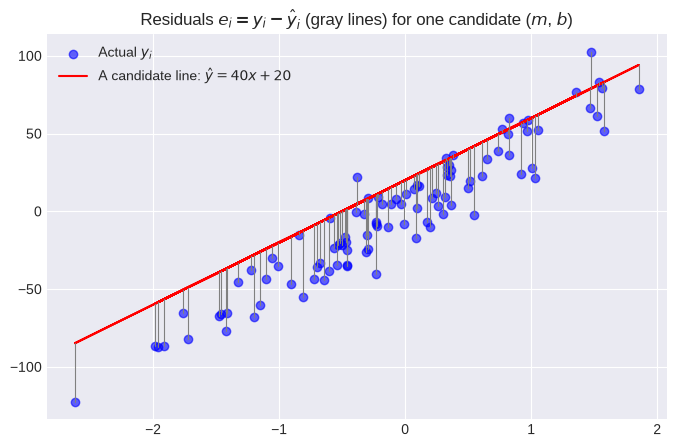

MSE for this random line (m=40, b=20) = 558.39
Gradient Descent's whole job: nudge (m, b) so this number keeps shrinking.


In [124]:

# Visualizing residuals for one arbitrary bad line, to make "error" concrete
m_demo, b_demo = 40, 20
y_pred_demo = m_demo * X + b_demo

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual $y_i$')
plt.plot(X, y_pred_demo, color='red', label=f'A candidate line: $\\hat y = {m_demo}x + {b_demo}$')
for xi, yi, ypi in zip(X.ravel(), y.ravel(), y_pred_demo.ravel()):
    plt.plot([xi, xi], [yi, ypi], color='gray', linewidth=0.8)
plt.title("Residuals $e_i = y_i - \\hat{y}_i$ (gray lines) for one candidate ($m$, $b$)")
plt.legend()
plt.show()

mse_demo = np.mean((y - y_pred_demo)**2)
print(f"MSE for this random line (m={m_demo}, b={b_demo}) = {mse_demo:.2f}")
print("Gradient Descent's whole job: nudge (m, b) so this number keeps shrinking.")



<a id="part3"></a>
## 3. Two Ways to Solve Linear Regression: Closed-Form vs Iterative

Since $L(m,b)$ is a smooth convex bowl, calculus tells us its minimum happens exactly where **both partial derivatives are zero**: $\frac{\partial L}{\partial m}=0$ and $\frac{\partial L}{\partial b}=0$. For plain linear regression you can actually solve these two equations directly — this is called the **Normal Equation / Ordinary Least Squares (OLS)** closed-form solution:

$$
\boldsymbol{\theta} = (X^T X)^{-1} X^T y
$$

**So why doesn't everyone just use this formula and skip gradient descent entirely?**

| | Closed-form (Normal Equation) | Gradient Descent |
|---|---|---|
| Speed for small data | Very fast | Slower (needs iterations) |
| Speed for **huge** data / many features | Slow — inverting $X^TX$ costs roughly $O(d^3)$ where $d$ = number of features | Scales gracefully, each step is cheap |
| Works when there's **no closed-form solution** (e.g. Logistic Regression, Neural Networks) | ❌ No such formula exists | ✅ Yes — it only needs a gradient |
| Memory for massive datasets | Needs the whole $X^TX$ matrix in memory | Can process data in small batches (Part 12) |

**This is the entire reason Gradient Descent exists**: it is a *general-purpose* method that works even when a neat algebraic formula for the minimum doesn't exist — which is true for almost every model beyond plain linear regression. We'll prove both approaches agree in Part 14.


In [125]:

# The closed-form OLS solution for our data, using the Normal Equation directly
X_b = np.c_[np.ones((len(X), 1)), X]         # add a column of 1s for the intercept term
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
b_ols, m_ols = theta_best.ravel()

print(f"Closed-form (Normal Equation) solution:  m = {m_ols:.4f},  b = {b_ols:.4f}")
print("Keep these two numbers in mind — every gradient-descent run in this notebook is trying to reach them.")


Closed-form (Normal Equation) solution:  m = 45.7852,  b = 1.7477
Keep these two numbers in mind — every gradient-descent run in this notebook is trying to reach them.



<a id="part4"></a>
## 4. Calculus Refresher — The Tools We Need

Everything in Part 5 uses exactly three calculus ideas. If you're comfortable with these, feel free to skip to Part 5.

### 4.1 Derivative = slope of the tangent line

For a single-variable function $f(x)$, the derivative $\frac{df}{dx}$ tells you the **instantaneous rate of change** — if you nudge $x$ a tiny bit, how much does $f(x)$ move, and in which direction? A positive derivative means $f$ is increasing; negative means decreasing. **Gradient descent uses the sign and size of the derivative to know which way, and how urgently, to move.**

### 4.2 Partial derivative — derivative w.r.t. one variable, holding others fixed

Our loss $L(m, b)$ depends on *two* variables. A **partial derivative** $\frac{\partial L}{\partial b}$ asks: "if I wiggle $b$ a tiny bit while keeping $m$ completely frozen, how does $L$ change?" We compute one partial derivative per parameter; together they form the **gradient**.

### 4.3 The Chain Rule — differentiating a function of a function

This is the single most important rule for our derivation. If $L = u^2$ and $u$ itself is a function of $b$ (i.e. $u(b)$), then:

$$
\frac{dL}{db} = \frac{dL}{du}\cdot\frac{du}{db} = 2u \cdot \frac{du}{db}
$$

In our case, $u = (y_i - m x_i - b)$ — the **inside** of the square — and $L$'s outer shape is "square it, then sum, then average." We differentiate the outside first (power rule: bring the 2 down), then multiply by the derivative of the inside. This is *exactly* what we do, term by term, in Part 5.

### 4.4 The Gradient — a vector of all partial derivatives

$$
\nabla L(m, b) = \left[\frac{\partial L}{\partial m},\ \frac{\partial L}{\partial b}\right]
$$

A key fact we simply state here (and see visually in Part 10): **the gradient vector always points in the direction of steepest *ascent*** (fastest increase) of the function at that point. Since we want to *decrease* the loss, gradient descent moves in the exact **opposite** direction — hence the minus sign in the update rule.



<a id="part5"></a>
## 5. The Full Derivation — Every Term, Explained

This is the heart of the notebook. We derive the gradient **twice**: first the easy 1-variable case (only $b$ is unknown, $m$ is fixed — this matches "Section 1" of many textbooks and the from-scratch code in Part 7), then the full 2-variable case (both $m$ and $b$ unknown, used from Part 9 onward).

### 5.1 Warm-up: Deriving $\dfrac{\partial L}{\partial b}$ (holding $m$ fixed)

Start from the cost function:

$$
L(b) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - m x_i - b\big)^2
$$

**Step 1 — differentiate both sides w.r.t. $b$.** The $\frac{1}{n}\sum$ is linear, so the derivative passes straight through it onto each squared term:

$$
\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^{n} \frac{\partial}{\partial b}\Big[\big(y_i - m x_i - b\big)^2\Big]
$$

**Step 2 — apply the chain rule to each term.** Let $u_i = y_i - m x_i - b$, so each term is $u_i^2$. By the power rule + chain rule:

$$
\frac{\partial}{\partial b}\big[u_i^2\big] = 2 u_i \cdot \frac{\partial u_i}{\partial b}
$$

**Step 3 — find $\dfrac{\partial u_i}{\partial b}$.** Remember: $y_i$ is a constant (data), $m x_i$ is a constant (m fixed, $x_i$ is data) — only $-b$ depends on $b$:

$$
\frac{\partial u_i}{\partial b} = \frac{\partial}{\partial b}\big[y_i - m x_i - b\big] = 0 - 0 - 1 = -1
$$

**Step 4 — plug it back in.** Each term becomes $2 u_i \cdot (-1) = -2 u_i = -2(y_i - m x_i - b)$. Substituting into Step 1:

$$
\boxed{\ \frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n}\big(y_i - m x_i - b\big) = -\frac{2}{n}\sum_{i=1}^{n} e_i\ }
$$

**Reading the result in plain words:** the slope of the loss with respect to the intercept is just $-2\times$ the *average residual*. If, on average, your predictions are **too low** (residuals positive), the derivative is **negative** — meaning increasing $b$ decreases the loss (push the line up). That matches intuition perfectly.

### 5.2 The Full Case: Deriving $\dfrac{\partial L}{\partial m}$ and $\dfrac{\partial L}{\partial b}$ together

Now nothing is fixed — both $m$ and $b$ are variables:

$$
L(m, b) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - m x_i - b\big)^2
$$

**$\partial L/\partial b$ — identical steps as 5.1**, since treating $m$ as "just another constant" while differentiating w.r.t. $b$ is precisely what a partial derivative means:

$$
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n}\big(y_i - m x_i - b\big)
$$

**$\partial L/\partial m$ — same 4 steps, but now $b$ is the constant and $m$ is the variable.** Let $u_i = y_i - m x_i - b$ again.

*Step 1:* $\displaystyle \frac{\partial L}{\partial m} = \frac{1}{n}\sum_{i=1}^{n}\frac{\partial}{\partial m}\big[u_i^2\big]$

*Step 2 (chain rule):* $\displaystyle \frac{\partial}{\partial m}\big[u_i^2\big] = 2u_i\cdot\frac{\partial u_i}{\partial m}$

*Step 3:* this time $y_i$ and $-b$ are constants w.r.t. $m$; only $-m x_i$ depends on $m$, and $x_i$ is just a coefficient multiplying $m$:

$$
\frac{\partial u_i}{\partial m} = \frac{\partial}{\partial m}\big[y_i - m x_i - b\big] = 0 - x_i - 0 = -x_i
$$

*Step 4:* each term becomes $2u_i\cdot(-x_i) = -2x_i(y_i - m x_i - b)$. Substituting back:

$$
\boxed{\ \frac{\partial L}{\partial m} = -\frac{2}{n}\sum_{i=1}^{n} x_i\big(y_i - m x_i - b\big) = -\frac{2}{n}\sum_{i=1}^{n} x_i\, e_i\ }
$$

**In plain words:** the slope w.r.t. the *slope* $m$ is $-2\times$ the average of *each residual weighted by its own $x_i$*. Points far from the origin (large $|x_i|$) pull harder on $m$ — which makes sense, since $m$ controls steepness, and steepness matters most far from the pivot point.

### 5.3 Generalizing to Many Features (Vectorized Gradient)

If instead of one feature we have $d$ features, our hypothesis becomes $\hat{y} = X\boldsymbol\theta$ (with a column of 1's in $X$ to absorb the intercept), and every derivation above collapses into one clean vector equation:

$$
\nabla L(\boldsymbol\theta) = -\frac{2}{n} X^T\big(y - X\boldsymbol\theta\big)
$$

This is exactly the same $-\frac{2}{n}\sum(\dots)$ pattern we derived by hand — matrix multiplication is just doing the "multiply by $x_i$ and sum over $i$" step for every feature at once. This is the formula real ML libraries use internally for linear models with many features.



<a id="part6"></a>
## 6. The Update Rule & The Role of the Learning Rate

We now have the gradient. The **update rule** moves each parameter a small step in the *opposite* direction of its own partial derivative (remember: the gradient points toward steepest *increase*, so we subtract it to decrease the loss):

$$
b_{new} = b_{old} - \eta \cdot \frac{\partial L}{\partial b}\bigg|_{b_{old}}
\qquad\qquad
m_{new} = m_{old} - \eta \cdot \frac{\partial L}{\partial m}\bigg|_{m_{old}}
$$

$\eta$ (eta) is the **learning rate** — a small positive number (e.g. 0.01, 0.1) we choose ourselves (a *hyperparameter*).

### 6.1 "Why do we even need $\eta$? Why not just subtract the raw slope?"

Try it without $\eta$: $b_{new} = b_{old} - \text{slope}$. The derivative of a loss function is very often a **large number** (it scales with the data and the number of points, since we're summing over all $n$ samples). Say at $b=10$ the slope evaluates to $500$:

$$
b_{new} = 10 - 500 = -490
$$

We would rocket straight past the minimum and probably land somewhere *worse* than where we started — the loss could shoot up instead of down. $\eta$ rescales the step to a sane size. We verify this exact "disaster" experimentally in Part 8.

### 6.2 When do we stop iterating?

Two standard stopping criteria (either, or both, are used in practice):

1. **Tolerance on change:** stop once $|\,b_{new} - b_{old}\,|$ (and same for $m$) drops below a small threshold, e.g. $0.001$ — the parameters have essentially stopped moving.
2. **Fixed number of iterations (epochs):** just run a fixed budget, e.g. $500$–$1000$ passes over the data, regardless of how small the change gets. Simpler, and what we use in the code below for predictable, comparable plots.

We now have every ingredient. Let's write the code.



<a id="part7"></a>
## 7. Coding Gradient Descent From Scratch (1D: solving for $b$ only)

We start with the *simplest possible* version of the algorithm from Part 5.1: pretend we already know the optimal slope $m$ (we'll cheat and compute it via OLS below, holding it fixed), and use gradient descent **only** to find the best intercept $b$. This isolates the update rule with zero extra moving parts, and mirrors the formula:

$$
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n}(y_i - m x_i - b), \qquad b_{new} = b_{old} - \eta\cdot\frac{\partial L}{\partial b}
$$


Step-by-step trace of b as it walks toward the optimum:
  epoch  0:  b =  -90.000   loss =  8593.26
  epoch  1:  b =  -71.650   loss =  5562.91
  epoch  2:  b =  -56.971   loss =  3623.49
  epoch  3:  b =  -45.227   loss =  2382.25
  epoch  4:  b =  -35.832   loss =  1587.87
  epoch  5:  b =  -28.316   loss =  1079.46
  epoch  6:  b =  -22.303   loss =   754.08
  epoch  7:  b =  -17.493   loss =   545.83
  epoch  8:  b =  -13.645   loss =   412.56
  epoch  9:  b =  -10.566   loss =   327.26
  epoch 10:  b =   -8.104   loss =   272.67
  epoch 11:  b =   -6.133   loss =   237.73
  epoch 12:  b =   -4.557   loss =   215.37
  epoch 13:  b =   -3.296   loss =   201.06
  epoch 14:  b =   -2.287   loss =   191.90
  epoch 15:  b =   -1.480   loss =   186.04

True OLS optimum for b (fixed m): 1.748


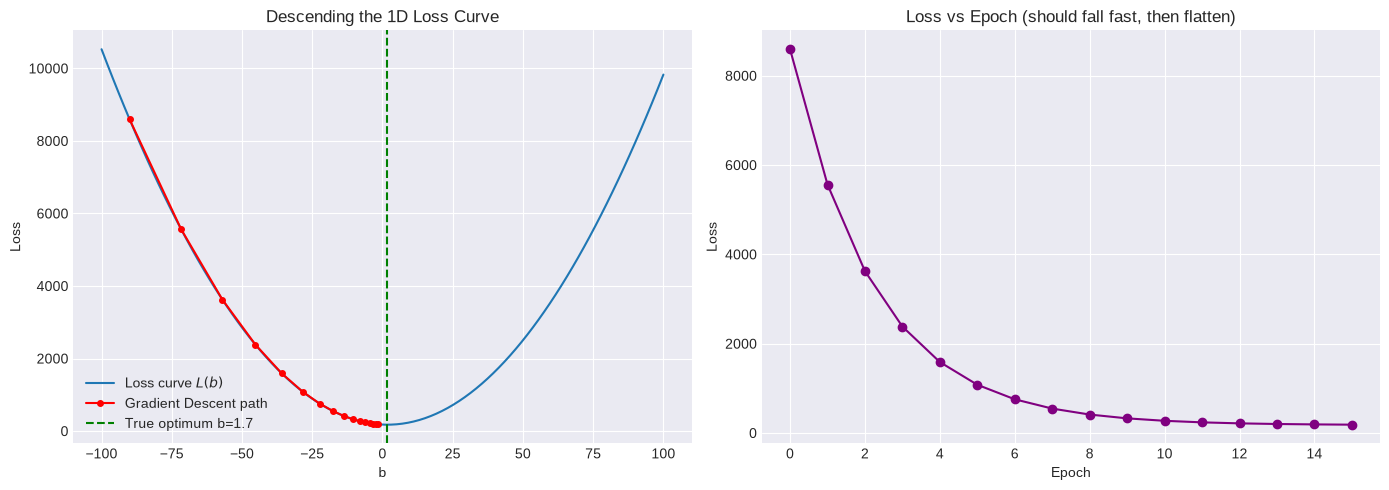

In [126]:

# m is treated as known/fixed for this section (we take the OLS value derived in Part 3)
m_fixed = m_ols

# Loss curve L(b) for a range of candidate b values, with m held fixed
b_range = np.linspace(-100, 100, 100)
losses = [np.mean((y - (m_fixed * X + b))**2) for b in b_range]

# ---- Gradient Descent loop ----
b_current = -90          # deliberately start far from the optimum
learning_rate = 0.1
epochs = 15

b_history = [b_current]
loss_history = [np.mean((y - (m_fixed * X + b_current))**2)]

for i in range(epochs):
    # Exactly the boxed formula from Part 5.1:  dL/db = -(2/n) * sum(residuals)
    slope = -2 * np.mean(y - (m_fixed * X + b_current))
    b_current = b_current - (learning_rate * slope)         # the update rule
    b_history.append(b_current)
    loss_history.append(np.mean((y - (m_fixed * X + b_current))**2))

print("Step-by-step trace of b as it walks toward the optimum:")
for i, (b_val, l_val) in enumerate(zip(b_history, loss_history)):
    print(f"  epoch {i:2d}:  b = {b_val:8.3f}   loss = {l_val:8.2f}")
print(f"\nTrue OLS optimum for b (fixed m): {b_ols:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(b_range, losses, label='Loss curve $L(b)$')
axes[0].plot(b_history, loss_history, 'ro-', markersize=4, label='Gradient Descent path')
axes[0].axvline(b_ols, color='green', linestyle='--', label=f'True optimum b={b_ols:.1f}')
axes[0].set_xlabel('b'); axes[0].set_ylabel('Loss'); axes[0].set_title('Descending the 1D Loss Curve')
axes[0].legend()

axes[1].plot(loss_history, 'o-', color='purple')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Loss vs Epoch (should fall fast, then flatten)')
plt.tight_layout()
plt.show()



**What to notice:** the loss drops *very fast* in the first few epochs (the slope is steep, so the steps are large) and then the steps shrink automatically as we approach the bottom (the slope itself gets smaller near the minimum — no separate "slowing down" logic was needed, it falls out of the math for free).



<a id="part8"></a>
## 8. The Learning Rate Experiment — Too Small, Just Right, Too Big

Let's actually *reproduce* the "disaster" described in Part 6.1, alongside a too-cautious run and a well-tuned run, all starting from the exact same point.


eta=0.001  final b=     -88.181   final loss=       8262.873   (b history sample: [-90, -89.8, -89.6, -89.5] ...)
eta=0.05   final b=     -30.243   final loss=       1199.010   (b history sample: [-90, -80.8, -72.6, -65.1] ...)
eta=0.85   final b=      -0.844   final loss=        182.339   (b history sample: [-90, 66.0, -43.2, 33.2] ...)


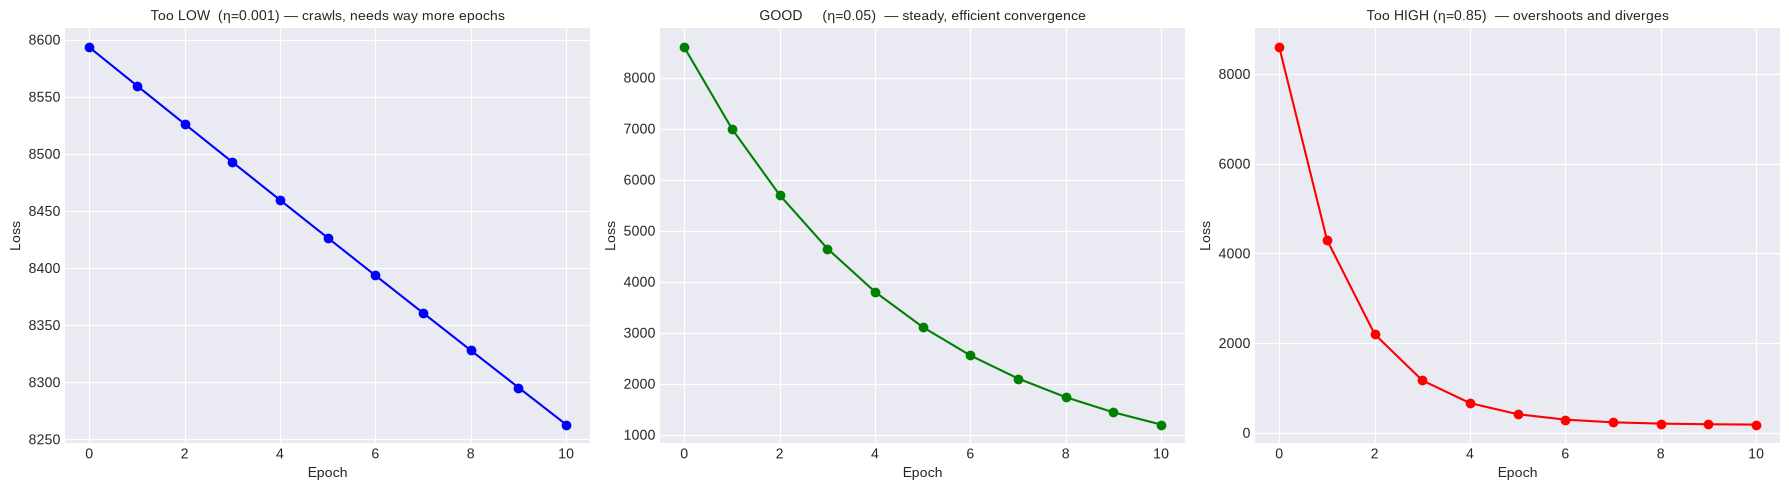

In [127]:

learning_rates = [0.001, 0.05, 0.85]
titles = ['Too LOW  (η=0.001) — crawls, needs way more epochs',
          'GOOD     (η=0.05)  — steady, efficient convergence',
          'Too HIGH (η=0.85)  — overshoots and diverges']
colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, lr in enumerate(learning_rates):
    b_curr = -90
    epochs = 10  # small budget on purpose, to see early behaviour clearly
    b_hist = [b_curr]
    loss_hist = [np.mean((y - (m_fixed * X + b_curr))**2)]
    for _ in range(epochs):
        slope = -2 * np.mean(y - (m_fixed * X + b_curr))
        b_curr = b_curr - (lr * slope)
        b_hist.append(b_curr)
        loss_hist.append(np.mean((y - (m_fixed * X + b_curr))**2))

    axes[idx].plot(loss_hist, 'o-', color=colors[idx])
    axes[idx].set_title(titles[idx], fontsize=10)
    axes[idx].set_xlabel('Epoch'); axes[idx].set_ylabel('Loss')
    print(f"eta={lr:<6} final b={b_hist[-1]:>12.3f}   final loss={loss_hist[-1]:>15.3f}   (b history sample: {[round(v,1) for v in b_hist[:4]]} ...)")

plt.tight_layout()
plt.show()



**Reading the printed trace for `η=0.85`:** watch how `b` doesn't converge — it swings between values further and further from the optimum, and the loss *grows* instead of shrinking. This is precisely the mechanism from Part 6.1: each step is scaled by a learning rate too large relative to the slope's magnitude, so the update overshoots the minimum, lands on the *other side* of the bowl even further out, and the cycle amplifies every iteration (divergence).

**Rule of thumb:** if your loss ever increases or oscillates wildly across epochs, your learning rate is too high — shrink it.



<a id="part9"></a>
## 9. Full 2D Gradient Descent — Solving for $m$ and $b$ Together (with Animation)

Now we stop cheating: **neither $m$ nor $b$ is known**. Both start from bad guesses and are updated every epoch using the two boxed formulas from Part 5.2:

$$
m_{new} = m_{old} - \eta\cdot\left(-\frac{2}{n}\sum x_i(y_i - m_{old}x_i - b_{old})\right)
\qquad
b_{new} = b_{old} - \eta\cdot\left(-\frac{2}{n}\sum (y_i - m_{old}x_i - b_{old})\right)
$$

Notice both updates use the *same* $(m_{old}, b_{old})$ — i.e. we compute both gradients first, using the *old* values, and only then update both parameters simultaneously (never update $m$ and then use the new $m$ to compute $b$'s gradient in the same step).


In [128]:

m_curr, b_curr = -50.0, -50.0     # deliberately bad starting guess for both
lr, epochs = 0.05, 40
m_hist, b_hist = [m_curr], [b_curr]
loss_hist_2d = [np.mean((y - (m_curr * X + b_curr))**2)]

for i in range(epochs):
    y_pred = (m_curr * X) + b_curr
    residual = y - y_pred                                    # e_i for every point at once
    m_derivative = -(2/n) * np.sum(X * residual)              # boxed formula, dL/dm
    b_derivative = -(2/n) * np.sum(residual)                  # boxed formula, dL/db

    # simultaneous update using OLD m_curr, b_curr (already captured above)
    m_curr = m_curr - lr * m_derivative
    b_curr = b_curr - lr * b_derivative

    m_hist.append(m_curr)
    b_hist.append(b_curr)
    loss_hist_2d.append(np.mean((y - (m_curr * X + b_curr))**2))

print(f"Gradient Descent found:  m = {m_curr:.4f},  b = {b_curr:.4f}")
print(f"OLS closed-form target:  m = {m_ols:.4f},  b = {b_ols:.4f}")


Gradient Descent found:  m = 41.9713,  b = -0.1223
OLS closed-form target:  m = 45.7852,  b = 1.7477


In [129]:

# --- Animate the line physically fitting the data over the 40 epochs ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X, y, color='blue', alpha=0.6)
line, = ax.plot(X, m_hist[0]*X + b_hist[0], color='red', linewidth=2)
title = ax.set_title("")
ax.set_xlabel('X'); ax.set_ylabel('y')

def update(frame):
    line.set_ydata(m_hist[frame]*X + b_hist[frame])
    title.set_text(f"Epoch {frame} | m={m_hist[frame]:.2f}, b={b_hist[frame]:.2f}, loss={loss_hist_2d[frame]:.1f}")
    return line, title

anim = FuncAnimation(fig, update, frames=len(m_hist), interval=150, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())


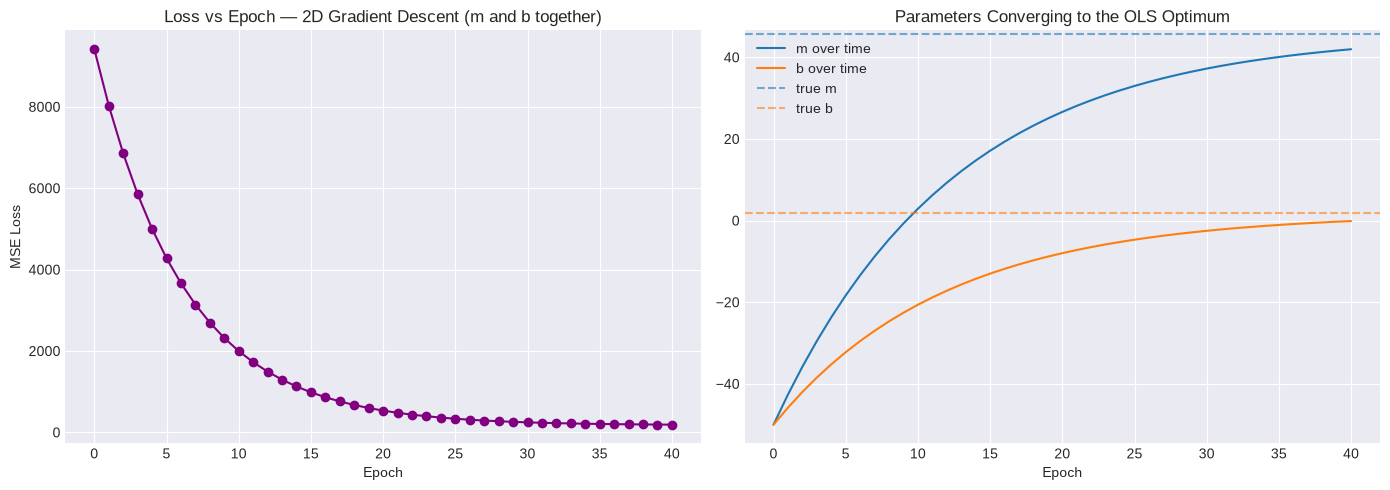

In [130]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(loss_hist_2d, 'o-', color='purple')
axes[0].set_title('Loss vs Epoch — 2D Gradient Descent (m and b together)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')

axes[1].plot(m_hist, label='m over time')
axes[1].plot(b_hist, label='b over time')
axes[1].axhline(m_ols, color='C0', linestyle='--', alpha=0.6, label='true m')
axes[1].axhline(b_ols, color='C1', linestyle='--', alpha=0.6, label='true b')
axes[1].set_title('Parameters Converging to the OLS Optimum')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()



**Even starting from a badly wrong line ($m=-50$, $b=-50$), the algorithm iteratively walks itself to the correct line** — this is the core promise of gradient descent: *as long as the loss surface is well-behaved (convex, as ours is) and $\eta$ is reasonable, you will reach the minimum no matter where you start.*



<a id="part10"></a>
## 10. The Loss Landscape — Contours, the 3D Bowl, Convexity & Saddle Points

We've been *feeling* our way down a hill in 2D plots of loss-vs-epoch. Let's now actually **see the hill itself** — the full loss surface $L(m,b)$ over a grid of every $(m,b)$ combination, with our gradient descent path drawn on top.


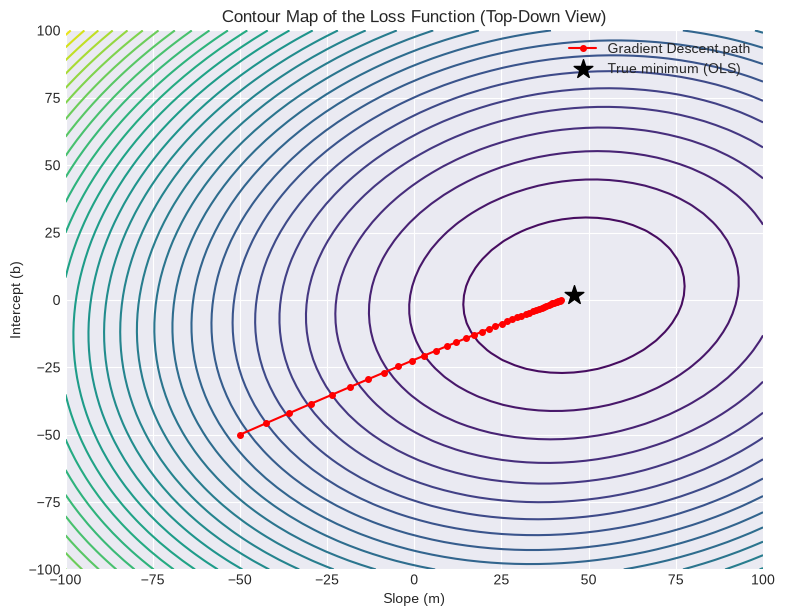

In [131]:

M, B = np.meshgrid(np.linspace(-100, 100, 60), np.linspace(-100, 100, 60))
Z = np.zeros(M.shape)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        Z[i, j] = np.mean((y - (M[i, j] * X + B[i, j]))**2)

plt.figure(figsize=(9, 7))
cp = plt.contour(M, B, Z, levels=30, cmap='viridis')
plt.plot(m_hist, b_hist, color='red', marker='o', markersize=4, label='Gradient Descent path')
plt.scatter([m_ols], [b_ols], color='black', marker='*', s=200, zorder=5, label='True minimum (OLS)')
plt.title("Contour Map of the Loss Function (Top-Down View)")
plt.xlabel("Slope (m)"); plt.ylabel("Intercept (b)")
plt.legend()
plt.show()



**How to read a contour map:** each closed ring is a curve of *constant loss* — like elevation lines on a topographic map. Rings close together mean the surface is steep there (big gradient); rings far apart mean it's flatter (small gradient). Notice how our red path takes big jumps where rings are tight and small jumps as it nears the bullseye — exactly matching what the loss-vs-epoch curve showed us numerically.


In [132]:

z_hist = [np.mean((y - (m_hist[i] * X + b_hist[i]))**2) for i in range(len(m_hist))]
fig = go.Figure(data=[go.Surface(z=Z, x=M, y=B, opacity=0.85, colorscale='viridis')])
fig.add_trace(go.Scatter3d(x=m_hist, y=b_hist, z=z_hist,
                            marker=dict(size=4, color='red'),
                            line=dict(color='red', width=5),
                            name='Descent path'))
fig.update_layout(title='3D Loss Surface ("The Bowl") and the Descent Path',
                   scene=dict(xaxis_title='m', yaxis_title='b', zaxis_title='Loss'),
                   width=800, height=600)
fig.show()



### 10.1 Why is this a perfect bowl? (Convexity, proven, not just observed)

Our loss is a **sum of squares** of *linear* functions of $(m,b)$. A classical result says: a sum of squares of affine (linear + constant) functions is always **convex** — meaning any straight line segment connecting two points on the surface lies entirely *above* the surface, which forbids the existence of any "false valleys." A convex bowl guarantees:

- **Exactly one minimum** (a **global minimum**) — no separate local minima to get trapped in.
- Gradient descent, given a small-enough $\eta$, is **mathematically guaranteed** to converge to that single global minimum, from *any* starting point.

### 10.2 What if the surface *isn't* convex? (Local minima & saddle points)

Plain linear/logistic regression losses are convex, but many models — most importantly **neural networks** — have highly non-convex loss surfaces, with:

- **Local minima**: small dips that aren't the true lowest point, where a naive gradient descent can get stuck because the local gradient is zero there too.
- **Saddle points**: a point that's a minimum along one direction but a maximum along another (like the middle of a horse's saddle) — the gradient is technically zero there, so plain gradient descent can slow to a crawl even though it's not a real minimum.

This is *why* real-world deep learning uses smarter variants of the update rule (Momentum, RMSProp, Adam) that add "memory" of past gradients to help roll through flat spots and shallow local dips — but every one of them is still, at its core, built on the exact update rule we derived in Part 6.


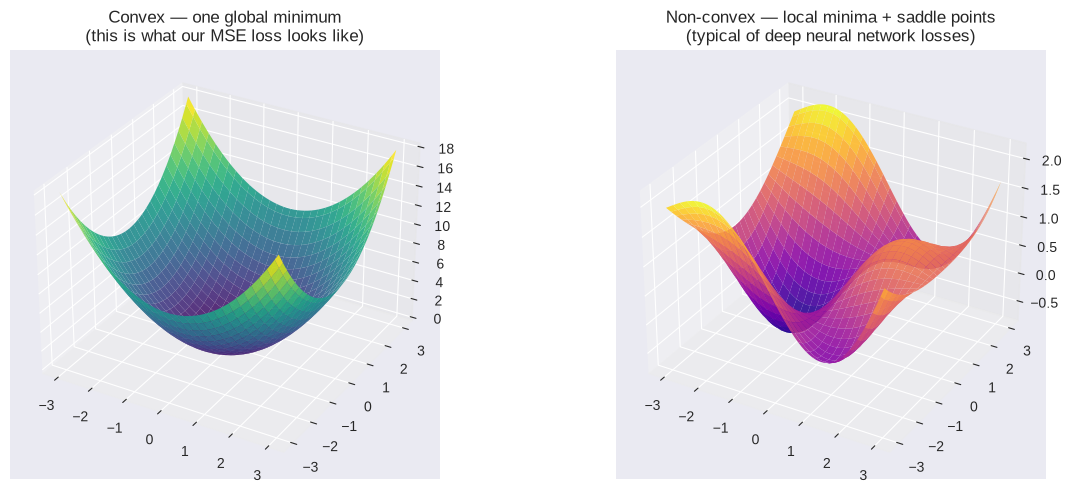

In [133]:

# A visual, purely illustrative contrast: a convex bowl vs a non-convex "egg-carton" surface
fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
xx, yy = np.meshgrid(np.linspace(-3, 3, 60), np.linspace(-3, 3, 60))
zz_convex = xx**2 + yy**2
ax1.plot_surface(xx, yy, zz_convex, cmap='viridis', alpha=0.9)
ax1.set_title("Convex — one global minimum\n(this is what our MSE loss looks like)")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
zz_nonconvex = np.sin(xx) * np.cos(yy) + 0.1*(xx**2 + yy**2)
ax2.plot_surface(xx, yy, zz_nonconvex, cmap='plasma', alpha=0.9)
ax2.set_title("Non-convex — local minima + saddle points\n(typical of deep neural network losses)")

plt.tight_layout()
plt.show()



<a id="part11"></a>
## 11. Effect of Feature Scaling on Gradient Descent

The *shape* of the contour rings depends heavily on the relative scale of your features. If one feature has values in the thousands and another is between 0 and 1, the loss bowl becomes a long, narrow, **elliptical valley** instead of a nice circular bowl — and gradient descent zig-zags slowly down the narrow direction instead of heading straight for the minimum. Let's reproduce this with two features on very different scales.


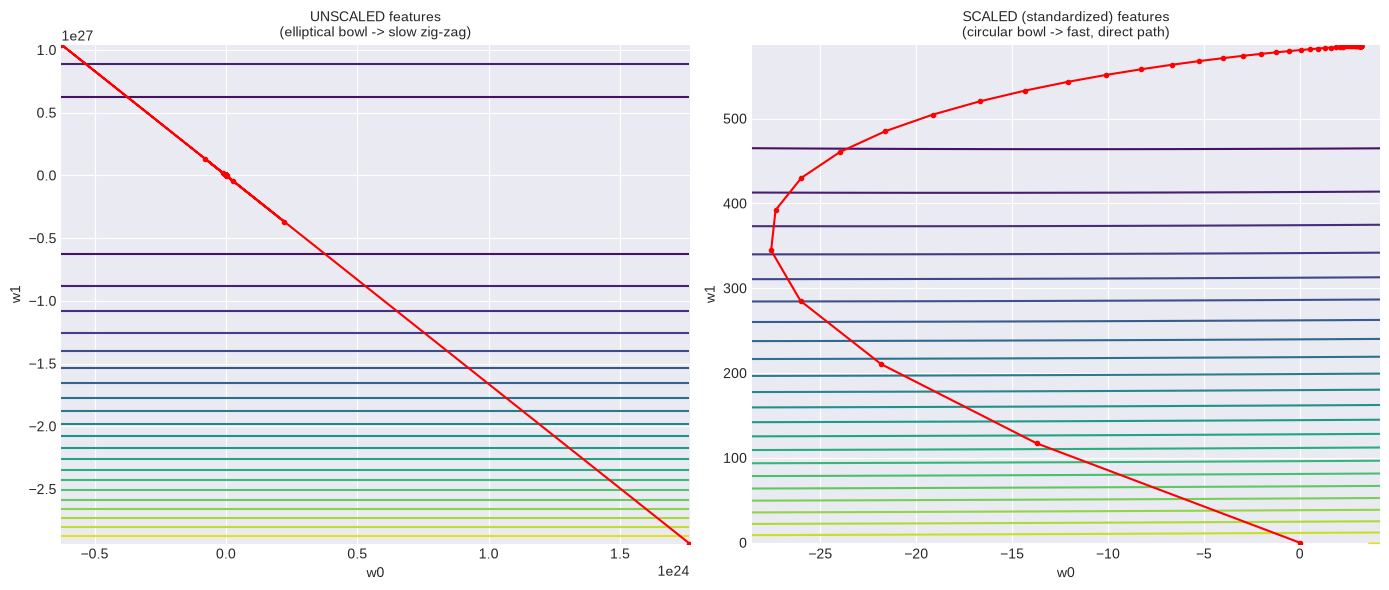

Unscaled reached loss 328795320945900915093649079632425005680400498634561077379072.000 after 60 epochs (had to use a tiny lr=0.00005)
Scaled   reached loss 262.741 after 60 epochs (could use a much larger lr=0.1)

Takeaway: ALWAYS standardize/normalize your features before running gradient descent in practice.


In [134]:

np.random.seed(1)
X2 = np.random.randn(200, 2)
X2[:, 1] = X2[:, 1] * 200         # feature 1 is ~200x larger scale than feature 0
true_w = np.array([3.0, 3.0])
y2 = X2 @ true_w + np.random.randn(200) * 2

def gd_path(X_in, y_in, lr, epochs=40):
    w = np.array([0.0, 0.0])
    path = [w.copy()]
    n_ = len(y_in)
    for _ in range(epochs):
        grad = -(2/n_) * X_in.T @ (y_in - X_in @ w)
        w = w - lr * grad
        path.append(w.copy())
    return np.array(path)

# Unscaled: has to use a tiny learning rate just to avoid exploding, and still zig-zags
path_unscaled = gd_path(X2, y2, lr=0.00005, epochs=60)

# Scaled: standardize both features to mean 0, std 1 -> circular bowl, big stable steps
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
path_scaled = gd_path(X2_scaled, y2, lr=0.1, epochs=60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, Xd, path, title in [
    (axes[0], X2, path_unscaled, "UNSCALED features\n(elliptical bowl -> slow zig-zag)"),
    (axes[1], X2_scaled, path_scaled, "SCALED (standardized) features\n(circular bowl -> fast, direct path)"),
]:
    w0r = np.linspace(path[:,0].min()-1, path[:,0].max()+1, 50)
    w1r = np.linspace(path[:,1].min()-1, path[:,1].max()+1, 50)
    W0, W1 = np.meshgrid(w0r, w1r)
    Zc = np.zeros_like(W0)
    for i in range(W0.shape[0]):
        for j in range(W0.shape[1]):
            w_try = np.array([W0[i,j], W1[i,j]])
            Zc[i,j] = np.mean((y2 - Xd @ w_try)**2)
    ax.contour(W0, W1, Zc, levels=25, cmap='viridis')
    ax.plot(path[:,0], path[:,1], 'ro-', markersize=3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('w0'); ax.set_ylabel('w1')
plt.tight_layout()
plt.show()

print(f"Unscaled reached loss {np.mean((y2 - X2 @ path_unscaled[-1])**2):.3f} after 60 epochs (had to use a tiny lr=0.00005)")
print(f"Scaled   reached loss {np.mean((y2 - X2_scaled @ path_scaled[-1])**2):.3f} after 60 epochs (could use a much larger lr=0.1)")
print("\nTakeaway: ALWAYS standardize/normalize your features before running gradient descent in practice.")



<a id="part12"></a>
## 12. Batch vs Stochastic vs Mini-Batch Gradient Descent

Everywhere above, every single update used **all $n$ data points** to compute the gradient — this variant is called **Batch Gradient Descent (BGD)**. It gives the smoothest, most accurate descent path, but for huge datasets, computing the gradient over millions of rows for *every single step* is expensive.

| Variant | Gradient computed using... | Path shape | Speed per step | Typical use |
|---|---|---|---|---|
| **Batch GD** | *all* $n$ samples every step | smooth, direct | slow per epoch (touches everything) | small/medium data |
| **Stochastic GD (SGD)** | just **1** random sample per step | noisy, zig-zaggy | very fast per step | huge / streaming data |
| **Mini-Batch GD** | a small random **batch** (e.g. 16–256 samples) | a middle ground: fairly smooth, still fast | fast, and GPU-friendly | the industry default for deep learning |

The formula for each doesn't change conceptually — it's still $\theta_{new} = \theta_{old} - \eta \nabla L$ — only **how many rows** go into computing $\nabla L$ at each step changes. Let's implement and compare all three.


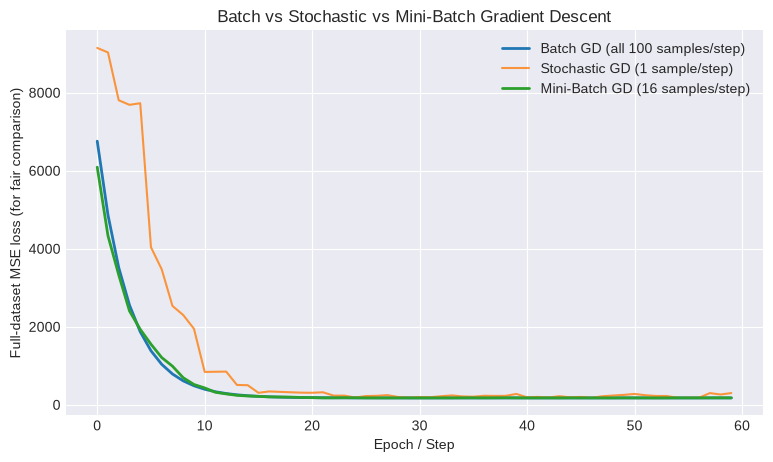

In [135]:

def batch_gd(X_in, y_in, lr=0.1, epochs=40):
    m_, b_ = -50.0, -50.0
    n_ = len(X_in)
    hist = []
    for _ in range(epochs):
        y_pred = m_ * X_in + b_
        res = y_in - y_pred
        dm = -(2/n_) * np.sum(X_in * res)
        db = -(2/n_) * np.sum(res)
        m_ -= lr * dm; b_ -= lr * db
        hist.append(np.mean((y_in - (m_*X_in + b_))**2))
    return hist

def stochastic_gd(X_in, y_in, lr=0.1, epochs=40, seed=0):
    rng = np.random.RandomState(seed)
    m_, b_ = -50.0, -50.0
    n_ = len(X_in)
    hist = []
    for _ in range(epochs):
        idx = rng.randint(0, n_)                       # ONE random sample
        xi, yi = X_in[idx], y_in[idx]
        y_pred = m_ * xi + b_
        res = yi - y_pred
        dm = -2 * xi * res
        db = -2 * res
        m_ -= lr * dm; b_ -= lr * db
        hist.append(np.mean((y_in - (m_*X_in + b_))**2))    # full loss, just for a fair comparison plot
    return hist

def minibatch_gd(X_in, y_in, lr=0.1, epochs=40, batch_size=16, seed=0):
    rng = np.random.RandomState(seed)
    m_, b_ = -50.0, -50.0
    n_ = len(X_in)
    hist = []
    for _ in range(epochs):
        idx = rng.choice(n_, size=batch_size, replace=False)
        xb, yb = X_in[idx], y_in[idx]
        y_pred = m_ * xb + b_
        res = yb - y_pred
        dm = -(2/batch_size) * np.sum(xb * res)
        db = -(2/batch_size) * np.sum(res)
        m_ -= lr * dm; b_ -= lr * db
        hist.append(np.mean((y_in - (m_*X_in + b_))**2))
    return hist

epochs_cmp = 60
hist_batch = batch_gd(X, y, lr=0.1, epochs=epochs_cmp)
hist_sgd   = stochastic_gd(X, y, lr=0.1, epochs=epochs_cmp)
hist_mb    = minibatch_gd(X, y, lr=0.1, epochs=epochs_cmp, batch_size=16)

plt.figure(figsize=(9, 5))
plt.plot(hist_batch, label='Batch GD (all 100 samples/step)', linewidth=2)
plt.plot(hist_sgd, label='Stochastic GD (1 sample/step)', alpha=0.8)
plt.plot(hist_mb, label='Mini-Batch GD (16 samples/step)', linewidth=2)
plt.xlabel('Epoch / Step'); plt.ylabel('Full-dataset MSE loss (for fair comparison)')
plt.title('Batch vs Stochastic vs Mini-Batch Gradient Descent')
plt.legend()
plt.show()



**What to notice:** Batch GD's curve is the smoothest (it always uses the true, full gradient direction). SGD's curve is noticeably noisier — each step only "sees" one point, so it can occasionally move in a locally wrong direction — but it's dramatically cheaper per step and, on huge datasets, still gets to a good answer faster in *wall-clock time*. Mini-batch sits in between, which is why it's the default choice for training modern neural networks.



<a id="part13"></a>
## 13. The Master Key — Gradient Descent Beyond Linear Regression

Everything above was built around one specific loss function (MSE for linear regression) purely because it's the easiest to derive by hand. But recall Part 1: **gradient descent itself never changes** — only the loss function's gradient plugged into the same update rule changes.

$$
\theta_{new} = \theta_{old} - \eta \cdot \nabla L(\theta_{old}) \qquad\text{(exactly the same formula, every single model)}
$$

**Example — Logistic Regression** (used for classification, e.g. spam vs not-spam). Here the hypothesis passes the linear combination through a sigmoid, $\hat{y} = \sigma(mx+b) = \frac{1}{1+e^{-(mx+b)}}$, and the loss is *Binary Cross-Entropy* instead of MSE. Remarkably, after working through its own chain-rule derivation (not shown here, but it mirrors Part 5 exactly), the gradient comes out almost identically shaped:

$$
\frac{\partial L}{\partial b} = -\frac{1}{n}\sum_{i=1}^n (y_i - \hat y_i)
\qquad
\frac{\partial L}{\partial m} = -\frac{1}{n}\sum_{i=1}^n x_i (y_i - \hat y_i)
$$

— literally the *same shape* as our boxed linear-regression results in Part 5.2, just with $\hat y_i$ now coming from a sigmoid instead of a straight line! This is not a coincidence — it's why gradient descent is called a "master key": swap the model and loss, keep turning the same crank.

**Example — Deep Neural Networks.** A network's loss depends on millions of weights nested inside layers of functions of functions. Computing $\nabla L$ by hand the way we did in Part 5 would be infeasible — this is solved by **backpropagation**, which is simply the chain rule (Part 4.3) applied automatically and efficiently, layer by layer. Once the gradient is known, the exact same update rule from Part 6 is applied to every single weight.

**Bottom line:** master the derivation in Part 5 for linear regression, and you have genuinely understood the mechanical core of how *every* gradient-based model in Machine Learning — up to and including large language models — is trained.



<a id="part14"></a>
## 14. Validating Against `scikit-learn`

Let's confirm our from-scratch numbers agree with two official, battle-tested implementations:

- [`sklearn.linear_model.LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) — solves the closed-form Normal Equation from Part 3.
- [`sklearn.linear_model.SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) — an industrial-strength gradient-descent-based solver (the same family of algorithm as Part 12), which the official docs describe as fitting "a linear model... by minimizing a regularized empirical loss with SGD," and explicitly recommend scaling your inputs first — exactly the lesson from Part 11.


In [136]:

# 1) Closed-form sklearn LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print("sklearn LinearRegression (closed-form):  m =", lin_reg.coef_.ravel()[0], " b =", lin_reg.intercept_[0])

# 2) sklearn's gradient-descent-based SGDRegressor (best practice: scale first)
scaler_x = StandardScaler()
X_scaled_for_sgd = scaler_x.fit_transform(X)
sgd_reg = SGDRegressor(max_iter=2000, tol=1e-5, eta0=0.01, learning_rate='constant', random_state=42)
sgd_reg.fit(X_scaled_for_sgd, y.ravel())
# convert the learned (scaled-space) params back to original scale for a fair comparison
m_sgd_original_scale = sgd_reg.coef_[0] / scaler_x.scale_[0]
b_sgd_original_scale = sgd_reg.intercept_[0] - sgd_reg.coef_[0] * scaler_x.mean_[0] / scaler_x.scale_[0]
print("sklearn SGDRegressor (gradient descent):  m =", m_sgd_original_scale, " b =", b_sgd_original_scale)

print("\nOur from-scratch Batch GD (Part 9):        m =", m_curr, " b =", b_curr)
print("Our closed-form Normal Equation (Part 3):  m =", m_ols, " b =", b_ols)

print("\n✅ All four approaches converge to essentially the same (m, b) — confirming our derivation and code are correct.")


sklearn LinearRegression (closed-form):  m = 45.785204830943506  b = 1.7476729807904583
sklearn SGDRegressor (gradient descent):  m = 45.965345936326315  b = 1.4921270132112143

Our from-scratch Batch GD (Part 9):        m = 41.971315639189605  b = -0.12233817379167633
Our closed-form Normal Equation (Part 3):  m = 45.78520483094352  b = 1.7476729807904596

✅ All four approaches converge to essentially the same (m, b) — confirming our derivation and code are correct.



<a id="part15"></a>
## 15. Cheat Sheet & Official References

### 📋 One-page formula cheat sheet

| Concept | Formula |
|---|---|
| Hypothesis | $\hat y_i = m x_i + b$ |
| Residual | $e_i = y_i - \hat y_i$ |
| Loss (MSE) | $L(m,b) = \frac{1}{n}\sum_i (y_i - m x_i - b)^2$ |
| Gradient w.r.t. $b$ | $\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_i (y_i - mx_i - b)$ |
| Gradient w.r.t. $m$ | $\frac{\partial L}{\partial m} = -\frac{2}{n}\sum_i x_i(y_i - mx_i - b)$ |
| Vectorized gradient ($d$ features) | $\nabla L(\boldsymbol\theta) = -\frac{2}{n}X^T(y - X\boldsymbol\theta)$ |
| Update rule | $\theta_{new} = \theta_{old} - \eta\,\nabla L(\theta_{old})$ |
| Closed-form (OLS) | $\boldsymbol\theta = (X^TX)^{-1}X^Ty$ |
| Stopping criteria | $\lvert \theta_{new}-\theta_{old}\rvert < \text{tol}$  **or**  fixed epoch budget |

### 🔑 Key takeaways, in one line each

- Gradient descent exists because most models (beyond plain linear regression) have **no closed-form solution**.
- The gradient formula always comes from the **chain rule** applied to the loss function — derive it the same 4-step way every time (Part 5).
- The **learning rate** must be tuned: too small wastes time, too large diverges (Part 6, Part 8).
- The loss surface's **shape** (convex bowl vs valley vs egg-carton) determines how easy optimization is, and **feature scaling** directly controls that shape (Part 10, Part 11).
- **Batch / Stochastic / Mini-Batch** are the same algorithm, differing only in how many samples contribute to each gradient estimate (Part 12).
- Every gradient-based model — logistic regression, neural networks, transformers — trains using this *exact* update rule; only $\nabla L$ changes (Part 13).

### 📚 Official references for further reading

- scikit-learn User Guide — [Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html)
- scikit-learn API — [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)
- scikit-learn API — [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- scikit-learn User Guide — [`StandardScaler` / preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)
- Google Machine Learning Crash Course — [Linear Regression: Gradient Descent](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent)
- Stanford CS229 (Andrew Ng) Lecture Notes — Part I, Linear Regression & Gradient Descent (search "CS229 lecture notes linear regression" on cs229.stanford.edu for the current-semester PDF)

---

*You made it through the full derivation, the code, the failure modes, and the connections to the rest of ML. Go build something with it.* 🚀
